# YouNiverse: Mapping YouTube's Hidden Communities

## Project Abstract

This project aims to uncover the hidden architecture of YouTube's content landscape. Instead of relying on explicit channel categories, we build a graph based on **audience overlap**. 

The core logic is this: for each user, we find the **Top-K channels** they comment on the most. We then create edges *only* between these Top-K channels. This creates a high-signal graph of true audience affinity.

This notebook documents the end-to-end pipeline by calling scripts from our `src` directory:

1.  **Data Loading:** Ingest channel and video metadata using `src.data.load`.
2.  **Graph Construction:** Stream comments to build the Top-K co-commenter graph using `src.scripts.process_data`.
3.  **Graph Analysis:** Normalize the graph (using our new commenter counts), run community detection, and calculate metrics using `src.models.analysis`.
4.  **Results:** Analyze and visualize the resulting communities.

## 1. Setup and Imports

First, we set up our environment, adding the `src` directory to the path and importing our custom-built modules.

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# Add src to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import our custom modules
from src.data import data_loader 
from src.scripts import process_data as data_processor
from src.models import model_analysis as model_analyzer

print("Successfully imported src modules.")

Successfully imported src modules.


### Configuration

We set our main analysis parameters here. These will be passed to our scripts.

In [2]:
# --- Parameters ---
MIN_SUBSCRIBERS = 200_000
MIN_EDGE_WEIGHT = 3 
MAX_COMMENT_ROWS = 150_000_000 

# --- New Top-K Parameters ---
TOP_K_PER_AUTHOR = 5
MIN_CHANS_FOR_PAIRS = 2
AUTHOR_FLUSH_THRESHOLD = 500_000

# --- Normalization Parameters ---
NORM_ALPHA = 0.5
NORM_BETA = 1.0
USE_ENGAGEMENT_METRIC = True # Use commenter counts

# --- File Paths (relative to project root) ---
CHANNEL_METADATA_PATH = "data/raw/df_channels_en.tsv" 
VIDEO_METADATA_PATH = "data/raw/yt_metadata_helper.feather"

EDGES_OUT_PATH = "data/processed/channel_edges.csv"
CHECKPOINT_PATH = "data/processed/edges_checkpoint.pkl"
STATE_PATH = "data/processed/state.json"
DICT_PATH = "data/processed/channel_commenter_counts.csv" # New file

NODES_OUT_PATH = "data/processed/chan_graph_node_metrics.csv"
COMMUNITIES_OUT_PATH = "data/processed/chan_graph_community_summary.csv"
VIZ_OUT_PATH = "reports/figures/network_viz.png"

# Ensure processed/reports directories exist
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

print("Configuration and paths set.")

Configuration and paths set.


## 2. Data Loading and Preparation

First, we load the metadata we need to build our helper maps.
1.  **Channel Metadata:** To get subscriber counts for filtering.
2.  **Video Metadata:** To create a lookup map from `video_id` to `channel_id`.

In [5]:
# Load data using our loader script
dfChannels = pd.read_csv(CHANNEL_METADATA_PATH,sep='\t')
videoDf = data_loader.load_video_metadata(local_path=VIDEO_METADATA_PATH, columns=["display_id", "channel_id"])

# Create helper maps using our processing script
v2c_map = data_processor.build_video_to_channel_map(videoDf)
channel_subset_map = data_processor.get_channel_subset_map(dfChannels, MIN_SUBSCRIBERS)

del videoDf # Free up memory

Loading Video Metadata...
Loaded 72,924,794 video records.
Creating 72,924,794 v2c mappings...


KeyboardInterrupt: 

## 3. Graph Construction: Streaming Comments

This is the most computationally intensive step. We call our `generate_edges` script.

This function will stream comments, process them using the **Top-K logic**, and save both `channel_edges.csv` and the new `channel_commenter_counts.csv`.

In [3]:
v2c_map = None
'''
edges_df = data_processor.generate_edges(
    v2c_map,
    EDGES_OUT_PATH,
    CHECKPOINT_PATH,
    STATE_PATH,
    DICT_PATH,
    max_rows=MAX_COMMENT_ROWS,
    top_k_per_author=TOP_K_PER_AUTHOR,
    min_chans_for_pairs=MIN_CHANS_FOR_PAIRS,
    author_flush_threshold=AUTHOR_FLUSH_THRESHOLD
)'''
edges_df = pd.read_csv(EDGES_OUT_PATH)
print(f"\nSuccessfully loaded {len(edges_df):,} edges.")
edges_df.head()


Successfully loaded 15,962,236 edges.


,src,dst,weight
0,UCBXNpF6k2n8dsI6nBH8q4sQ,UCM2ERkgV3P1_6MAyxa51rxA,17
1,UCBXNpF6k2n8dsI6nBH8q4sQ,UCpB959t8iPrxQWj7G6n0ctQ,26
2,UCBXNpF6k2n8dsI6nBH8q4sQ,UCtwD0AlYSlAYv7eXu8UxtEg,6
3,UCM2ERkgV3P1_6MAyxa51rxA,UCpB959t8iPrxQWj7G6n0ctQ,129
4,UCM2ERkgV3P1_6MAyxa51rxA,UCtwD0AlYSlAYv7eXu8UxtEg,9


## 4. Graph Analysis Pipeline

Now we run the main analysis pipeline. 

In [6]:
# Filter edges
edges_filtered, channels_indexed = model_analyzer.filter_edges(
    edges_df, dfChannels, MIN_SUBSCRIBERS, MIN_EDGE_WEIGHT
)

# NEW: Load the commenter counts
commenter_counts = data_loader.load_commenter_counts(DICT_PATH)

# Normalize edges, passing in the new counts
edges_normalized = model_analyzer.normalize_edges(
    edges_filtered, 
    channels_indexed, 
    commenter_counts, # Pass the new dict
    alpha=NORM_ALPHA, 
    beta=NORM_BETA, 
    use_engagement=USE_ENGAGEMENT_METRIC
)

# Build graph
G = model_analyzer.build_graph(edges_normalized, channels_indexed)

# Find communities and metrics
LCC, communities, node_df, comm_summary = model_analyzer.find_communities(
    G, nodes_out_path=NODES_OUT_PATH, comm_out_path=COMMUNITIES_OUT_PATH
)

Filtering edges: >200000 subs, >3 weight.
Filtered down to 1,681,752 edges.
Loading commenter counts from data/processed/channel_commenter_counts.csv...
Loaded 128,499 channel commenter counts.
Normalizing edge weights...
Using commenters (Top-K) (median=30) for normalization.
Building graph from normalized edges...
Graph built: 23,785 nodes, 1,681,752 edges
Finding Largest Connected Component (LCC)...
LCC:   23,781 nodes, 1,681,750 edges  (100.0% of nodes)
Detecting communities using Louvain...
Found 22 communities (modularity: 0.591)
Calculating node metrics (PageRank, Strength)...

✓ Saved node metrics and community summary.


## 5. Results and Interpretation

Our pipeline is complete. The results are saved in `data/processed/`. We can now load them for analysis.

### Result 1: Top 10 Largest Communities

This table shows the largest "galaxies" we found, sorted by the number of channels they contain.

In [13]:
print("Top 10 Largest Communities:")
print(comm_summary.head(10).to_string(index=False))

Top 10 Largest Communities:
 community  n_nodes  total_strength  avg_degree  avg_strength
         8     3765         7694076  127.709163   2043.579283
        11     3714         6280919  140.434841   1691.146742
         5     3625        18221320  237.116690   5026.571034
         2     2770         2390509   81.745487    862.999639
         0     2475         6183728  142.141414   2498.475960
         7     2230         6719445  186.553363   3013.204036
         6     1497         2244435  122.526386   1499.288577
        14      903         2098948  115.110742   2324.416390
        20      890          619612   66.840449    696.193258
         9      496         1010443   89.697581   2037.183468


### Result 2: Top 10 Most Influential Channels

This table shows the top 10 channels ranked by **PageRank**. PageRank identifies channels that are connected to *other* influential channels. These are the "super-connectors" in our YouNiverse.

In [14]:
print("Top 10 Channels by PageRank:")
print(node_df.nlargest(10, "pagerank")[
    ["name_cc", "category_cc", "subscribers_cc", "community", "degree", "pagerank"]
].to_string(index=False))

Top 10 Channels by PageRank:
         name_cc          category_cc  subscribers_cc  community  degree  pagerank
       PewDiePie               Gaming       101000000          7   11723  0.011249
        T-Series                Music       112139463          8    6648  0.007715
          DanTDM               Gaming        22100000          5    5351  0.004519
   jacksepticeye               Gaming        22833014          5    5683  0.004080
     PopularMMOs               Gaming        16900000          5    4795  0.003854
       Jake Paul       People & Blogs        19600000          5    5252  0.003844
Technical Guruji Science & Technology        13979890          8    3753  0.003841
      Markiplier               Gaming        24400000          5    5744  0.003641
  The ACE Family       People & Blogs        17600000          0    4621  0.003041
          SMTOWN                Music        19800000         14    4171  0.002963


### Result 3: Deep Dive into Community Profiles

We now call our analysis script to profile the top communities. This helps us put a name and a theme to our algorithmically-defined clusters.

In [16]:
# Run the analysis script
model_analyzer.analyze_communities(LCC, node_df, communities, max_show=5)

\n--- Deep Dive into Top 5 Communities ---
COMMUNITY 0
Size: 2475 nodes, 84146 edges
Top category: Howto & Style (1012/2475) ")
--------------------------------------------------------------------------------
Categories:
  Howto & Style        1012 (40.9%)
  People & Blogs        574 (23.2%)
  Entertainment         429 (17.3%)
  Comedy                173 (7.0%)
  Music                  84 (3.4%)
--------------------------------------------------------------------------------
Top 5 Channels (by Subscribers):
       name_cc    category_cc  strength  subscribers_cc
         shane         Comedy    215461        22300000
  JennaMarbles         Comedy     77280        19900000
 BuzzFeedVideo People & Blogs    112145        19400000
The ACE Family People & Blogs    219580        17600000
    Liza Koshy         Comedy     35171        17200000

COMMUNITY 1
Size: 5 nodes, 5 edges
Top category: Howto & Style (3/5) ")
------------------------------------------------------------------------------

### Result 4: Network Visualization

Finally, we call our visualization script to generate and save a plot of the graph.

**Nodes** are colored by their community and sized by their strength.

Generating network visualization...
Visualization subgraph: 187 nodes, 5014 edges
✓ Saved reports/figures/network_viz.png


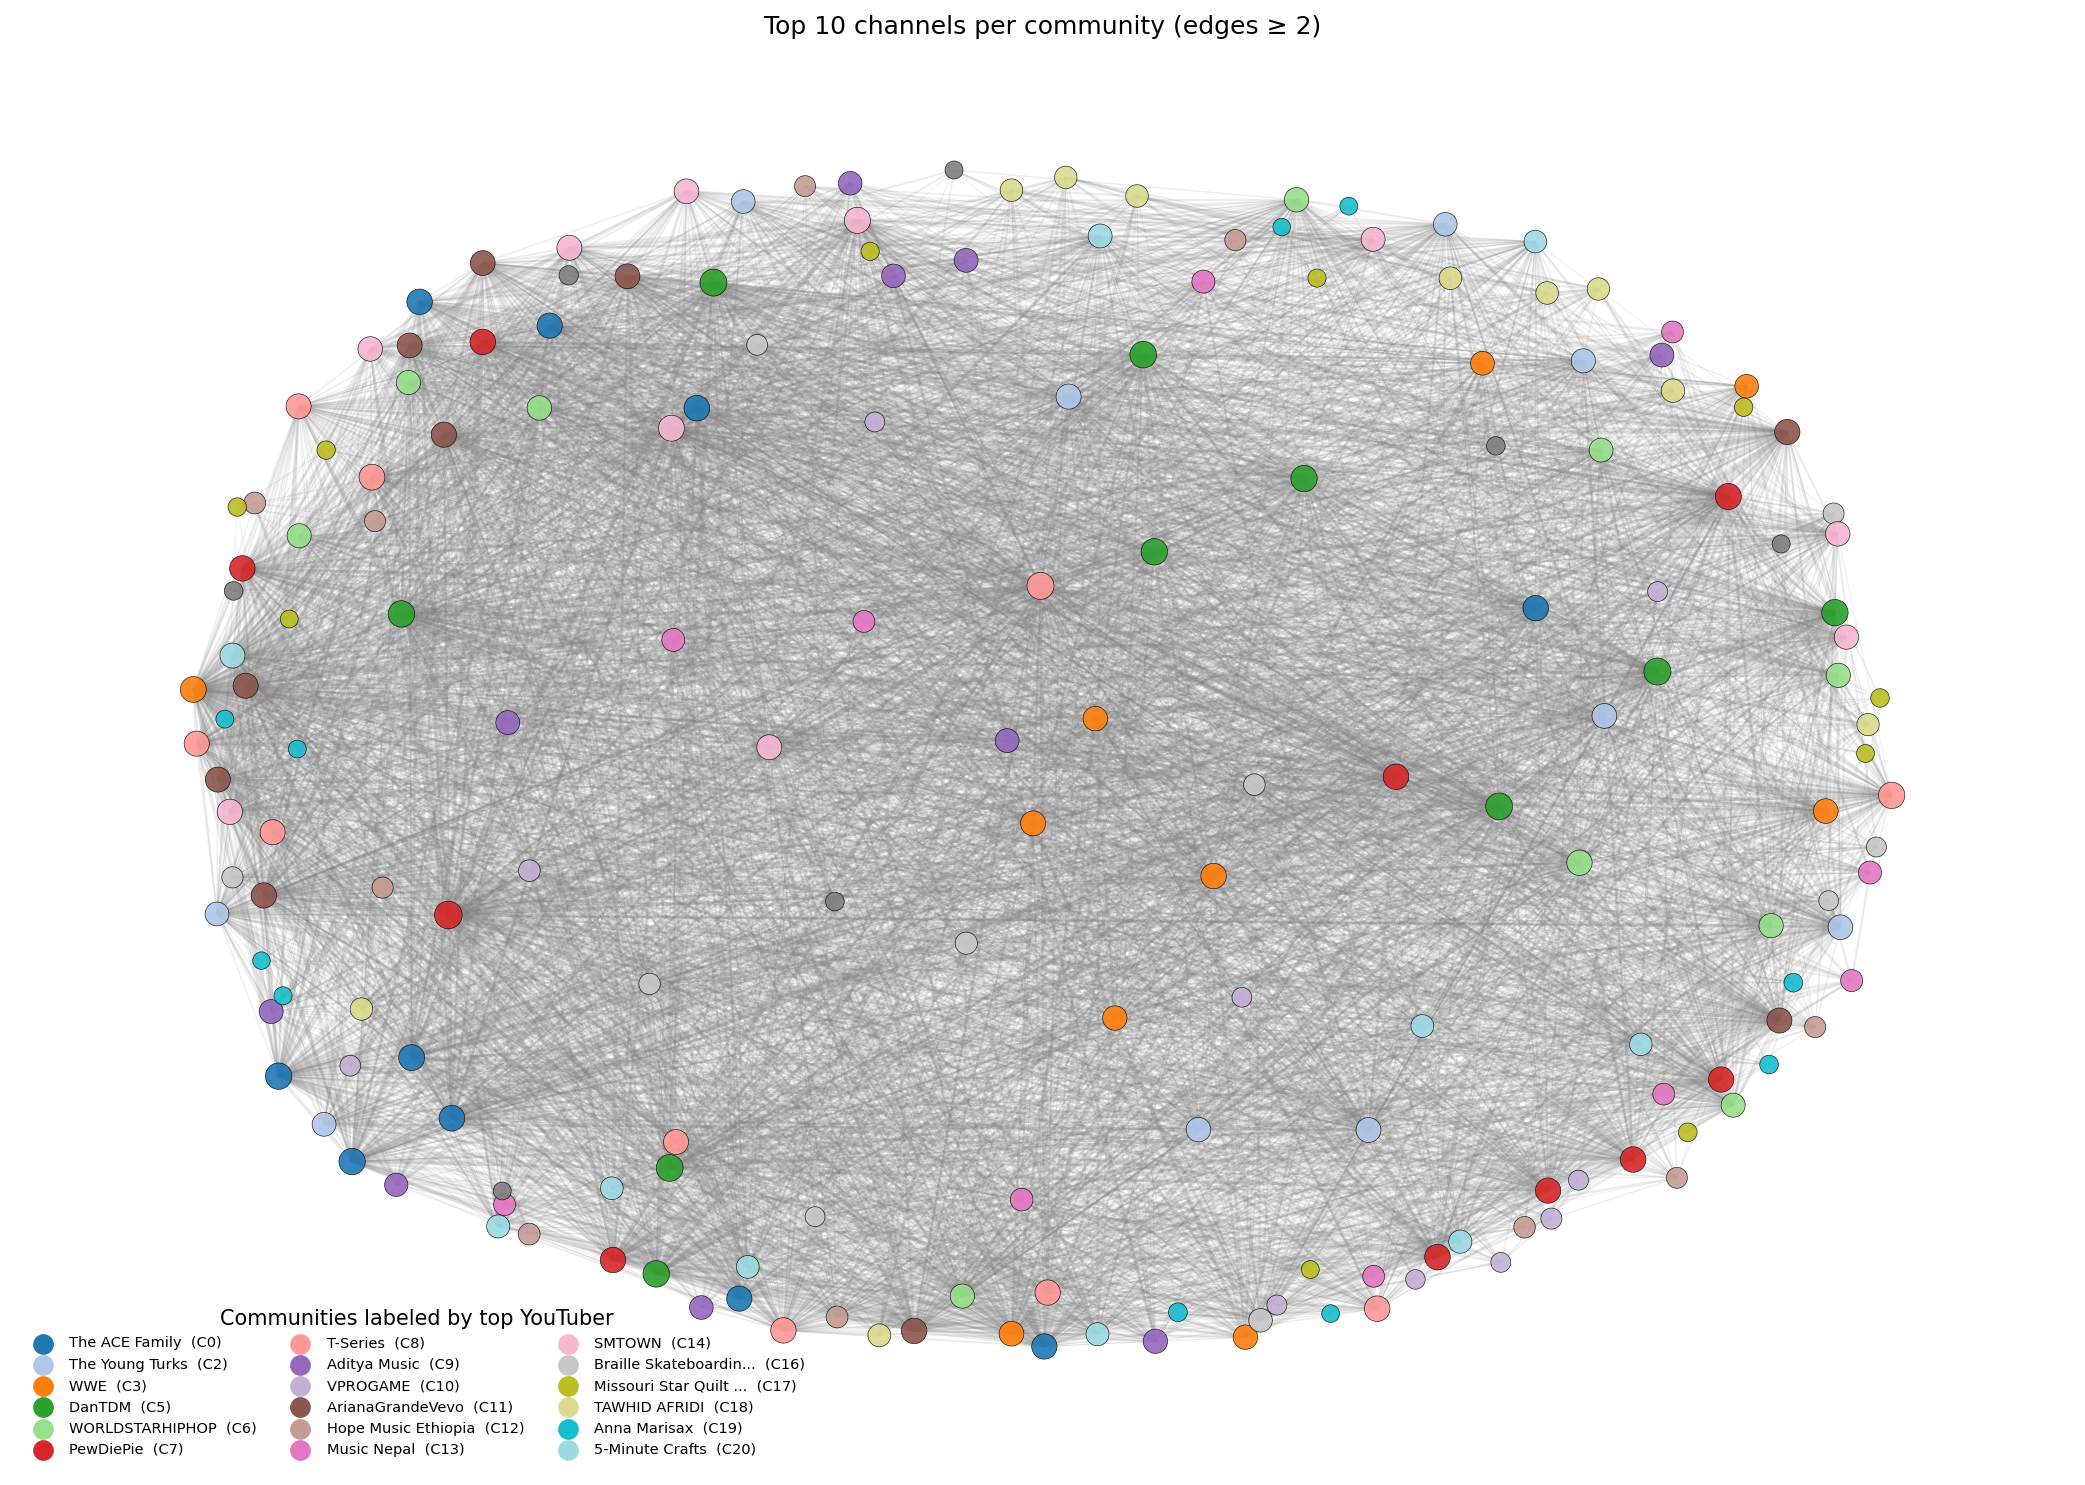

In [17]:
model_analyzer.visualize_network(
    LCC, 
    communities, 
    node_df, 
    viz_out_path=VIZ_OUT_PATH
)

## 6. Conclusion

This notebook successfully demonstrated a complete, scalable pipeline using our modular scripts. We processed over 150 million comments, constructed a high-signal **Top-K co-commenter graph**, and used a more accurate **engagement-based normalization** to identify distinct "galaxies" of channels.

The results show clear, thematically-consistent communities and identify their central channels. This proves the feasibility and sophistication of our approach for the P2 milestone.